In [1]:
import pandas 

ex = pandas.read_excel("temps_sommeil.xlsx")

In [3]:
import numpy,math

xbar = numpy.mean(ex['temps_de_sommeil'])
print("la moyenne est de temps de sommeil:"+str(round(xbar,2)))

la moyenne est de temps de sommeil:7.42


In [4]:
ecarte_type = numpy.std(ex['temps_de_sommeil'], ddof=1)
print("l'ecarte type de temps de sommeil est :"+str(round(ecarte_type,2)))

l'ecarte type de temps de sommeil est :0.57


In [5]:
variance = numpy.var(ex['temps_de_sommeil'], ddof=1)
print("la variance de temps de sommeil est:"+str(round(variance,2)))

la variance de temps de sommeil est:0.33


In [6]:
variance_biaisee = numpy.var(ex['temps_de_sommeil'])
print("la variance biaisee de temps de sommeil est:"+str(round(variance_biaisee,2)))

la variance biaisee de temps de sommeil est:0.32


Text(0.5, 1.0, 'histogramme :')

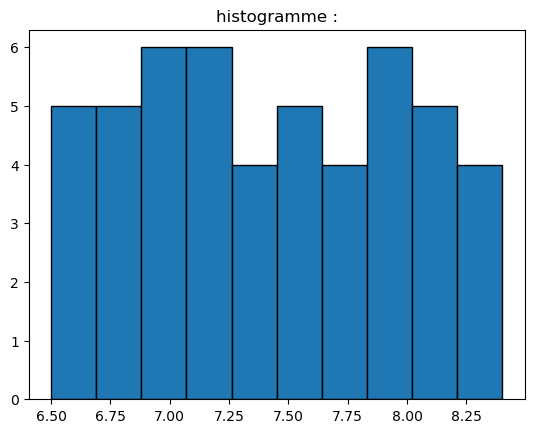

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline 
plt.hist(ex['temps_de_sommeil'], bins=10, edgecolor='black')
plt.title("histogramme :")

In [11]:
import scipy 
from scipy.stats import t
alpha = 0.05
n_ex = len(ex)
icinf = xbar-scipy.stats.t.ppf(1-alpha/2,n_ex-1)*ecarte_type/math.sqrt(n_ex-1)
round(icinf,2)
icsup = xbar+scipy.stats.t.ppf(1-alpha/2,n_ex-1)*ecarte_type/math.sqrt(n_ex-1)
round(icsup,2)
print('Intervalle de confiance IC sur moyenne du ecart type inconnu est : '+'['+str(round(icinf,2))+', '+str(round(icsup,2))+']')

Intervalle de confiance IC sur moyenne du ecart type inconnu est : [7.26, 7.59]


In [12]:
from scipy.stats import norm
ecarte_type2=2
icinf=xbar-scipy.stats.norm.ppf(1-alpha/2)*ecarte_type2/math.sqrt(n_ex)
round(icinf,2)
icsup=xbar+scipy.stats.norm.ppf(1-alpha/2)*ecarte_type2/math.sqrt(n_ex)
round(icsup,2)
print('Intervalle de confiance IC sur moyenne du ecart type connu est   : '+'['+str(round(icinf,2))+' , '+str(round(icsup,2))+']')


Intervalle de confiance IC sur moyenne du ecart type connu est   : [6.87 , 7.98]


In [16]:
scipy.stats.ttest_1samp(ex['temps_de_sommeil'],50)

TtestResult(statistic=-525.1424777382045, pvalue=1.47569537830472e-93, df=49)

l hypotése nulle  est : H0 : m0=50
l hypotése alternatif :H1 : m>50
Statistique test :
TtestResult(statistic=-525.1424777382045, pvalue=1.47569537830472e-93, df=49)


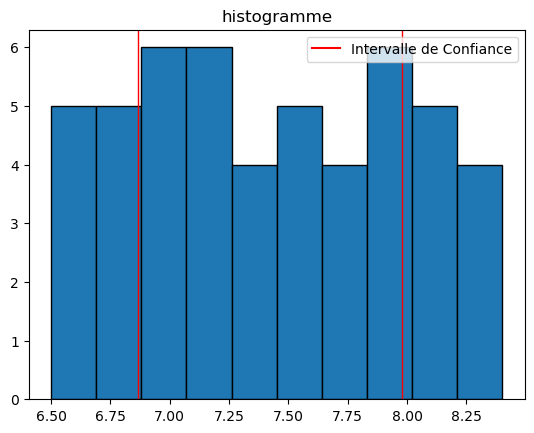

In [18]:
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
plt.hist(ex['temps_de_sommeil'], bins=10, edgecolor='black')
plt.title("histogramme")
plt.axvline(icinf, color='red', linewidth=1)
plt.axvline(icsup, color='red', linewidth=1)
plt.legend(handles=[mlines.Line2D([], [], color='red',markersize=6, label="Intervalle de Confiance")])
print('l hypotése nulle  est : H0 : m0=50')
print('l hypotése alternatif :H1 : m>50')
print('Statistique test :')
print(scipy.stats.ttest_1samp(ex['temps_de_sommeil'],50))